In [1]:
import pandas as pd
from chembl_webresource_client.new_client import new_client


In [3]:
target_id='CHEMBL4822'

activity=new_client.activity
records=activity.filter(
    target_chembl_id=target_id,
    standard_type='IC50'
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'pchembl_value'])

df=pd.DataFrame.from_records(records)
print(f"Raw records fetched: {len(df)}")
print(df.head(3))

Raw records fetched: 13697
                                    canonical_smiles molecule_chembl_id  \
0  CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...       CHEMBL406146   
1  CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...       CHEMBL406146   
2  CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...        CHEMBL78946   

  pchembl_value standard_units standard_value units  value  
0          6.38             nM          413.0    nM  413.0  
1          6.38             nM          413.0    nM  413.0  
2          8.70             nM            2.0    uM  0.002  


In [4]:
df=df.dropna(subset=['canonical_smiles','pchembl_value'])

df=df[df['standard_units']=='nM']

df=df.drop_duplicates(subset='canonical_smiles')

df=df.rename(columns={'canonical_smiles':'smiles','pchembl_value':'pIC50'})

df['pIC50']=df['pIC50'].astype(float)

df=df.reset_index(drop=True)

print(f"Clean compounds : {len(df)}")
print(df[['smiles','pIC50']].head())

Clean compounds : 8079
                                              smiles  pIC50
0  CC(C)C[C@H](NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O...   6.38
1  CC(C)C[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](N...   8.70
2  CCC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(C)=O)[C@@H]...   6.34
3  CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CC(=O)...   5.05
4  CC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](Cc1ccccc1...   5.25


In [5]:
print('===pIC50===')
print(df['pIC50'].describe())

===pIC50===
count    8079.000000
mean        6.775279
std         1.265238
min         2.540000
25%         5.810000
50%         6.890000
75%         7.730000
max        10.960000
Name: pIC50, dtype: float64


In [6]:
df['Class']=(df['pIC50']>=7.0).astype(int)

print('====Class Distribution====')
print(df['Class'].value_counts())

print("\nActive %:",round(df['Class'].mean()*100,1))

====Class Distribution====
Class
0    4291
1    3788
Name: count, dtype: int64

Active %: 46.9


In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_morgan(smiles, radius=2, nBits=2048):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp=AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
    return np.array(fp)

fingerprints=df['smiles'].apply(smiles_to_morgan)

failed=fingerprints.isnull().sum()
print(f"Failed Conversions: {failed}")

df=df[fingerprints.notnull()].reset_index(drop=True)
fingerprints=fingerprints.dropna().reset_index(drop=True)

X=np.vstack(fingerprints.values)

y_reg=df['pIC50'].values
y_clf=df['Class'].values

print(f"X shape : {X.shape}")
print(f"y_reg : {y_reg.shape}")
print(f"y_clf shape : {y_clf.shape}")

[12:42:17] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerator
[12:42:18] DEPRECATION WARNING: please use MorganGenerat

Failed Conversions: 0
X shape : (8079, 2048)
y_reg : (8079,)
y_clf shape : (8079,)


In [8]:
print(f"X shape : {X.shape}")
print(f"y_reg shape : {y_reg.shape}")
print(f"y_clf shape : {y_clf.shape}")

X shape : (8079, 2048)
y_reg shape : (8079,)
y_clf shape : (8079,)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [11]:
X_train, X_test, y_train,y_test=train_test_split(
    X,y_reg,test_size=0.2, random_state=42)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size : {X_test.shape[0]}")

Train size : 6463
Test size : 1616


In [12]:
rf_reg=RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

rf_reg.fit(X_train,y_train)

y_pred=rf_reg.predict(X_test)

r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"\nR2 Score : {r2:.3f}")
print(f"RMSE : {rmse:.3f}")


R2 Score : 0.680
RMSE : 0.714


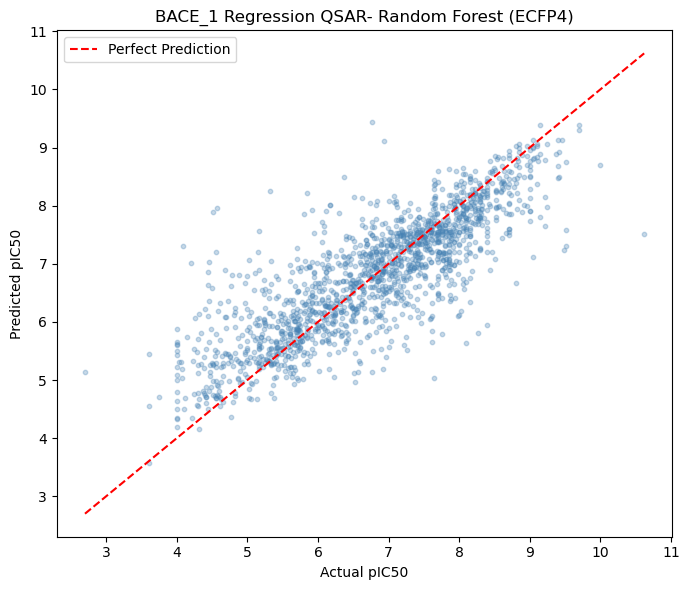

Plot saved.


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue',s=10)
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         'r--',linewidth=1.5,label='Perfect Prediction')

plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title('BACE_1 Regression QSAR- Random Forest (ECFP4)')
plt.legend()
plt.tight_layout()
plt.savefig('bace1_regression.png',dpi=150)
plt.show()

print("Plot saved.")

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [19]:
X_train_c, X_test_c, y_train_c,y_test_c=train_test_split(
    X,y_clf,test_size=0.2,random_state=42)

rf_clf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

rf_clf.fit(X_train_c,y_train_c)

y_pred_c=rf_clf.predict(X_test_c)

y_prob_c=rf_clf.predict_proba(X_test_c)[:,1]

acc=accuracy_score(y_test_c,y_pred_c)
auc=roc_auc_score(y_test_c,y_prob_c)
cm=confusion_matrix(y_test_c,y_pred_c)

print(f"Accuracy : {acc:.3f}")
print(f"ROC AUC : {auc:.3f}")
print(f"\nConfusion Matrix:")
print(cm)
print("\nClassification report:")
print(classification_report(y_test_c,y_pred_c))

Accuracy : 0.830
ROC AUC : 0.903

Confusion Matrix:
[[703 156]
 [119 638]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       859
           1       0.80      0.84      0.82       757

    accuracy                           0.83      1616
   macro avg       0.83      0.83      0.83      1616
weighted avg       0.83      0.83      0.83      1616



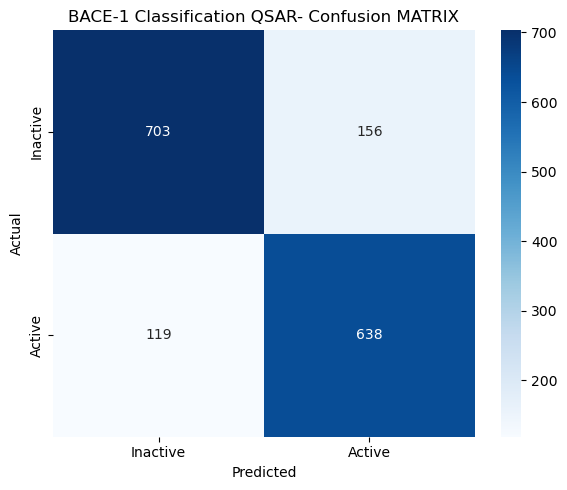

Plot saved.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inactive','Active'],
            yticklabels=['Inactive','Active'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('BACE-1 Classification QSAR- Confusion MATRIX')
plt.tight_layout()
plt.savefig('bace1_confusion_matrix.png',dpi=150)
plt.show()

print('Plot saved.')

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
importances=rf_clf.feature_importances_

importance_series=pd.Series(importances,
                            index=[f'Bit_{i}' for i in range(2048)])

top20=importance_series.sort_values(ascending=False).head(20)

print("Top 20 most important fingerprint bits:")
print(top20)

Top 20 most important fingerprint bits:
Bit_1535    0.013375
Bit_1928    0.012032
Bit_1980    0.010169
Bit_699     0.008680
Bit_1452    0.008295
Bit_1895    0.007747
Bit_674     0.007160
Bit_1840    0.006181
Bit_1871    0.005747
Bit_1457    0.005623
Bit_875     0.005518
Bit_873     0.005321
Bit_1060    0.005240
Bit_940     0.004852
Bit_1171    0.004670
Bit_216     0.004494
Bit_389     0.004465
Bit_1088    0.004346
Bit_59      0.004275
Bit_841     0.004113
dtype: float64


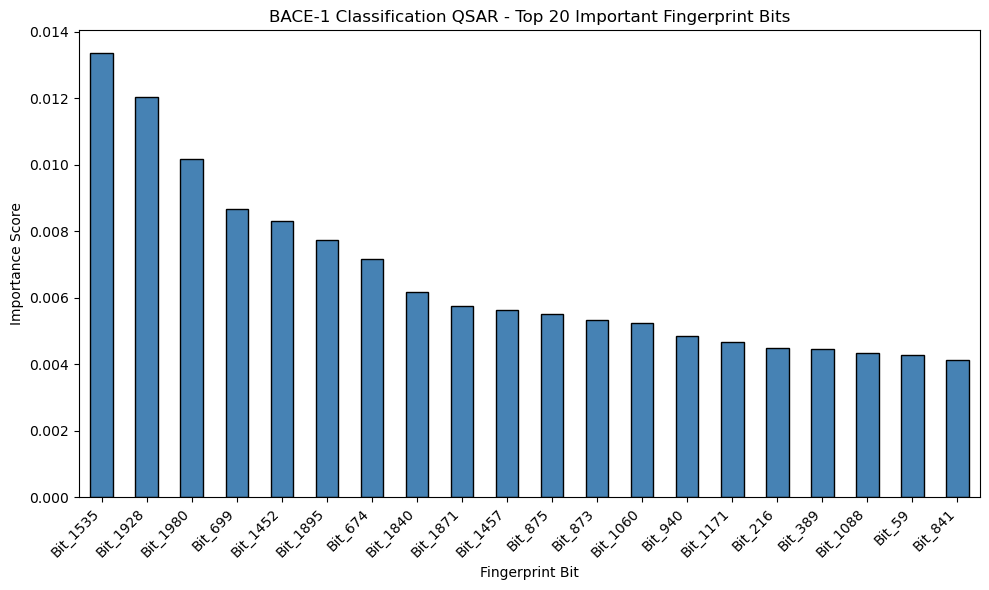

Plor saved.


In [23]:
plt.figure(figsize=(10,6))
top20.plot(kind='bar',color='steelblue',edgecolor='black')

plt.xlabel('Fingerprint Bit')
plt.ylabel('Importance Score')
plt.title('BACE-1 Classification QSAR - Top 20 Important Fingerprint Bits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bace1_feature_importance.png',dpi=150)
plt.show()

print("Plor saved.")

In [24]:
zero_bits=(importances==0).sum()
nonzero_bits=(importances>0).sum()

print(f"Total bits : 2048")
print(f"Bits with importances > 0: {nonzero_bits}")
print(f"Bits with importances = 0 : {zero_bits}")
print(f"Top bit importances : {top20.iloc[0]:.4f}")
print(f"Top bit index : {top20.index[0]}")

Total bits : 2048
Bits with importances > 0: 2028
Bits with importances = 0 : 20
Top bit importances : 0.0134
Top bit index : Bit_1535


In [25]:
import pandas as pd

summary={
    'Model':[
        'Random Forest Regressor',
        'Random Forest Classifier'
    ],
    'Task':[
        'pIC50 Predicition',
        'Active/Inactive classification'
    ],
    'Features':[
        'ECFP4 (Morgan r=2, nBits=2048)',
        'ECFP4 (Morgan r=2, nBits=2048)'
    ],
    'Metric 1':[
        'R2 = 0.680',
        'Accuracy=0.830'
    ],
    'Metric 2' : [
        'RMSE = 0.714',
        'ROC-AUC = 0.903'
    ]}
df_summary= pd.DataFrame(summary)
print(df_summary.to_string(index=False))

                   Model                           Task                       Features       Metric 1        Metric 2
 Random Forest Regressor              pIC50 Predicition ECFP4 (Morgan r=2, nBits=2048)     R2 = 0.680    RMSE = 0.714
Random Forest Classifier Active/Inactive classification ECFP4 (Morgan r=2, nBits=2048) Accuracy=0.830 ROC-AUC = 0.903


In [26]:
df[['smiles','pIC50','Class']].to_csv('bace1_cleaned.csv',index=False)
print("Saved: bace1_cleaned.csv")
print(f"Total compounds: {len(df)}")

Saved: bace1_cleaned.csv
Total compounds: 8079
